## Phase 1: Data Collection
### Task 1: Load the Customer Dataset
Dataset: Kaggle "Customer Personality Analysis" (marketing_campaign.csv).
The file is tab-separated, not comma-separated.

In [4]:
import pandas as pd

df = pd.read_csv('marketing_campaign.csv', sep='\t')
df.shape

(2240, 29)

## Phase 2: Exploratory Data Analysis (EDA)
### Task 1: Generate Summary Statistics
Use df.describe() and df.info() to understand the dataset's structure, 
data types, and basic statistics.

In [5]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

### Task 2: Check for Missing Values
Use df.isnull().sum() to identify which columns have missing data.

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

### Task 3: Histograms for Numerical Features
Visualize the distribution of every numerical feature to check for skew, 
spread, and unusual patterns.

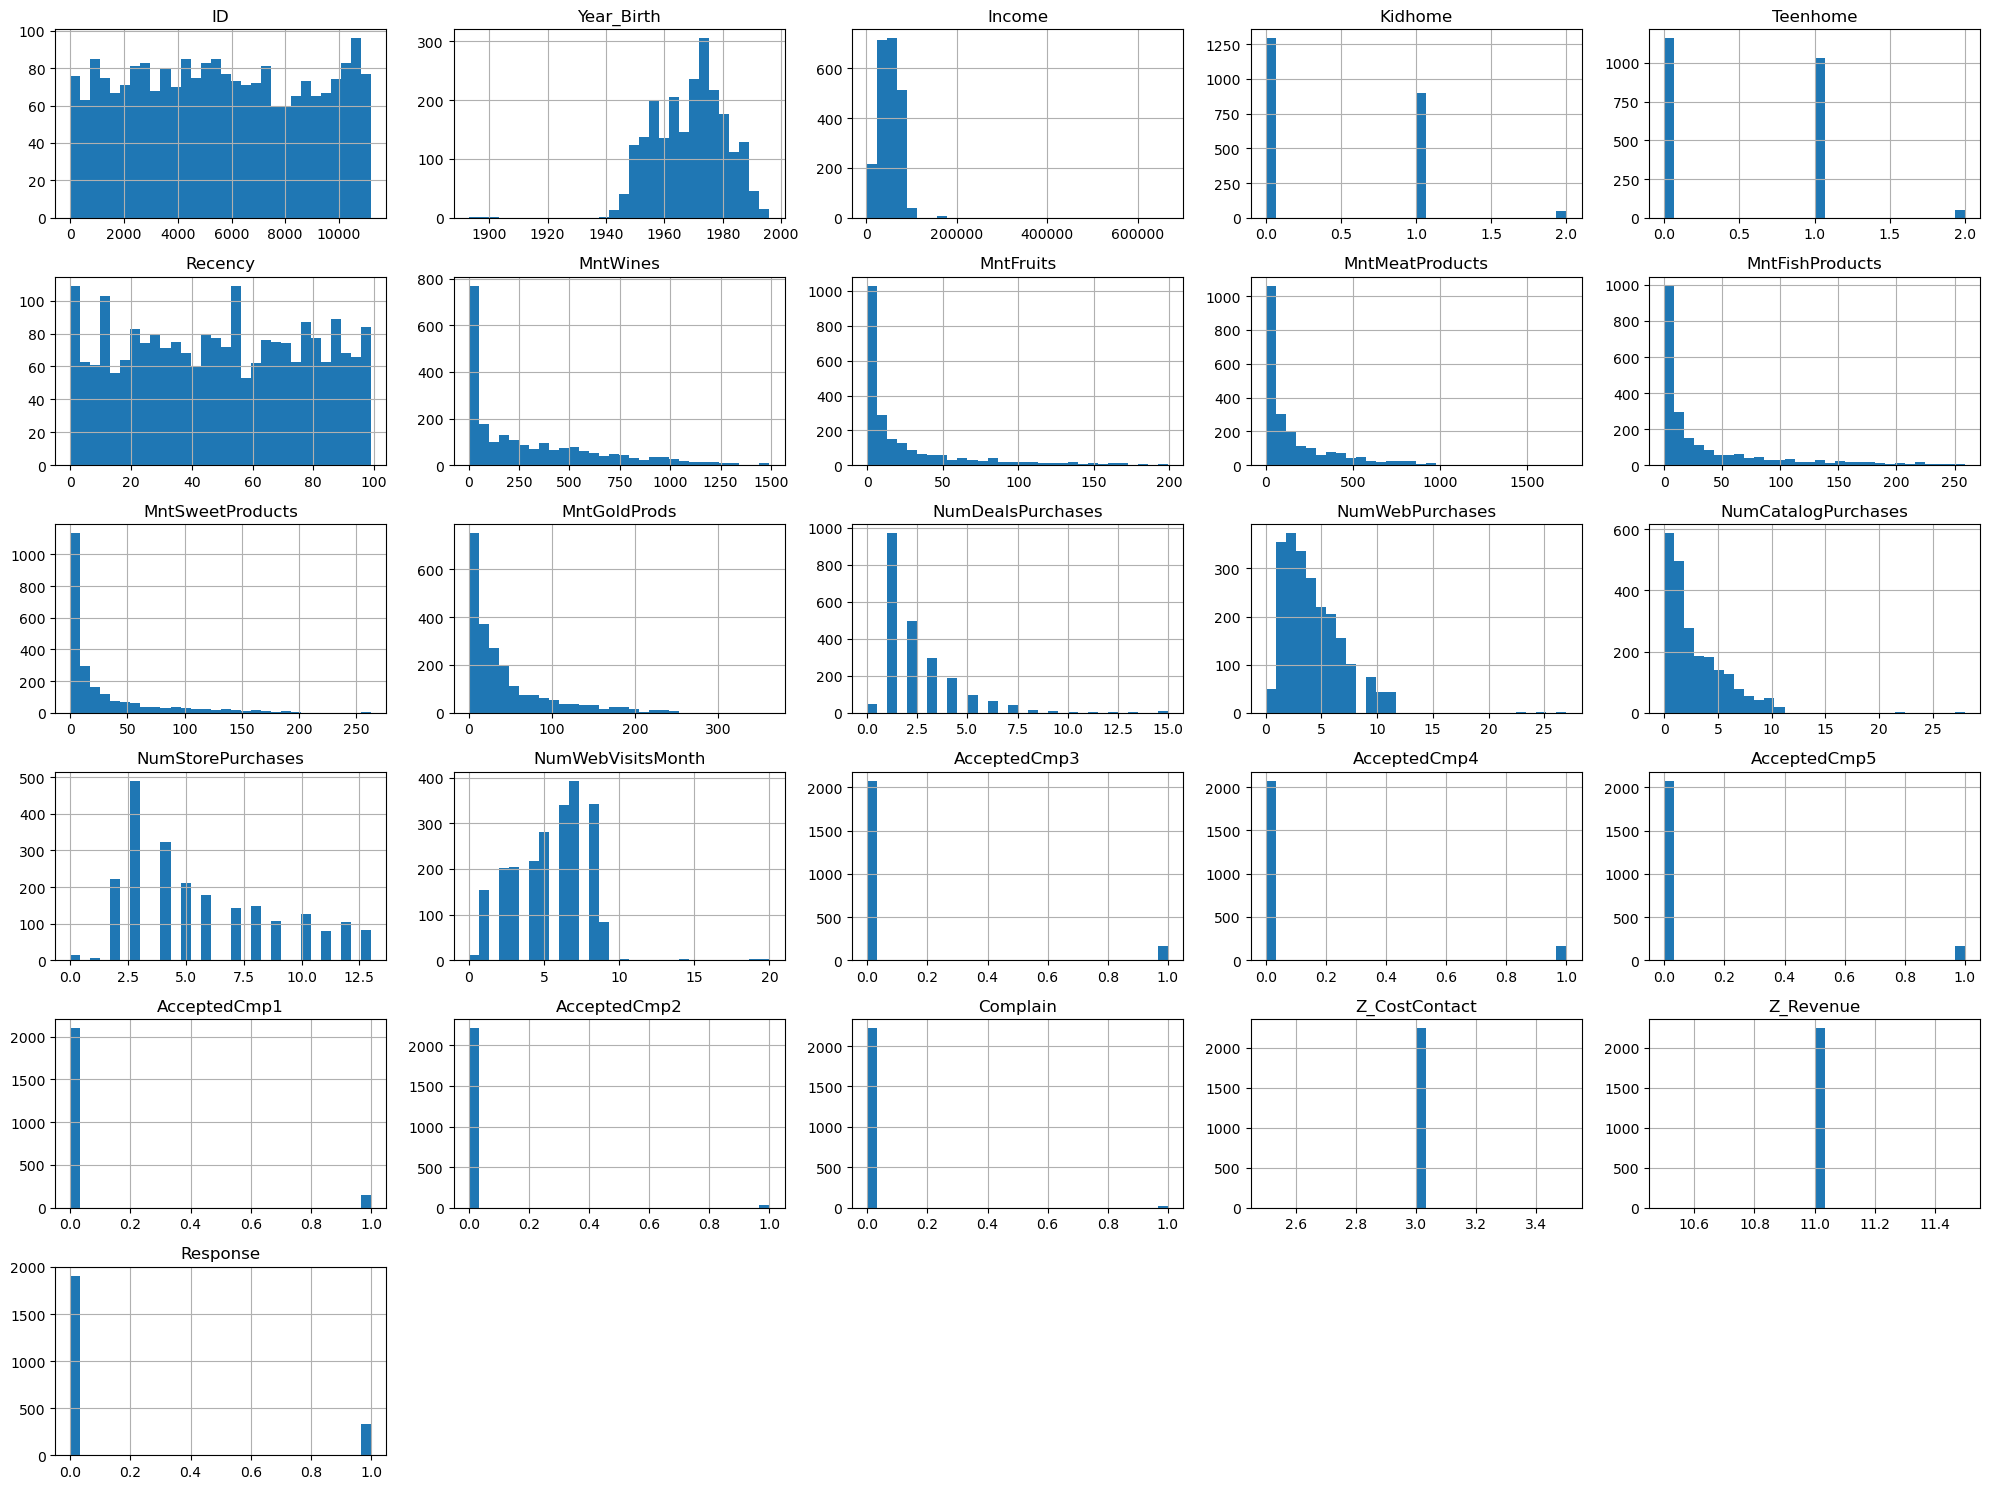

In [7]:
import matplotlib.pyplot as plt
import numpy as np

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

df[num_cols].hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.show()

### Task 4: Boxplots for Outlier Identification
Use boxplots on numerical features to visually spot outliers.

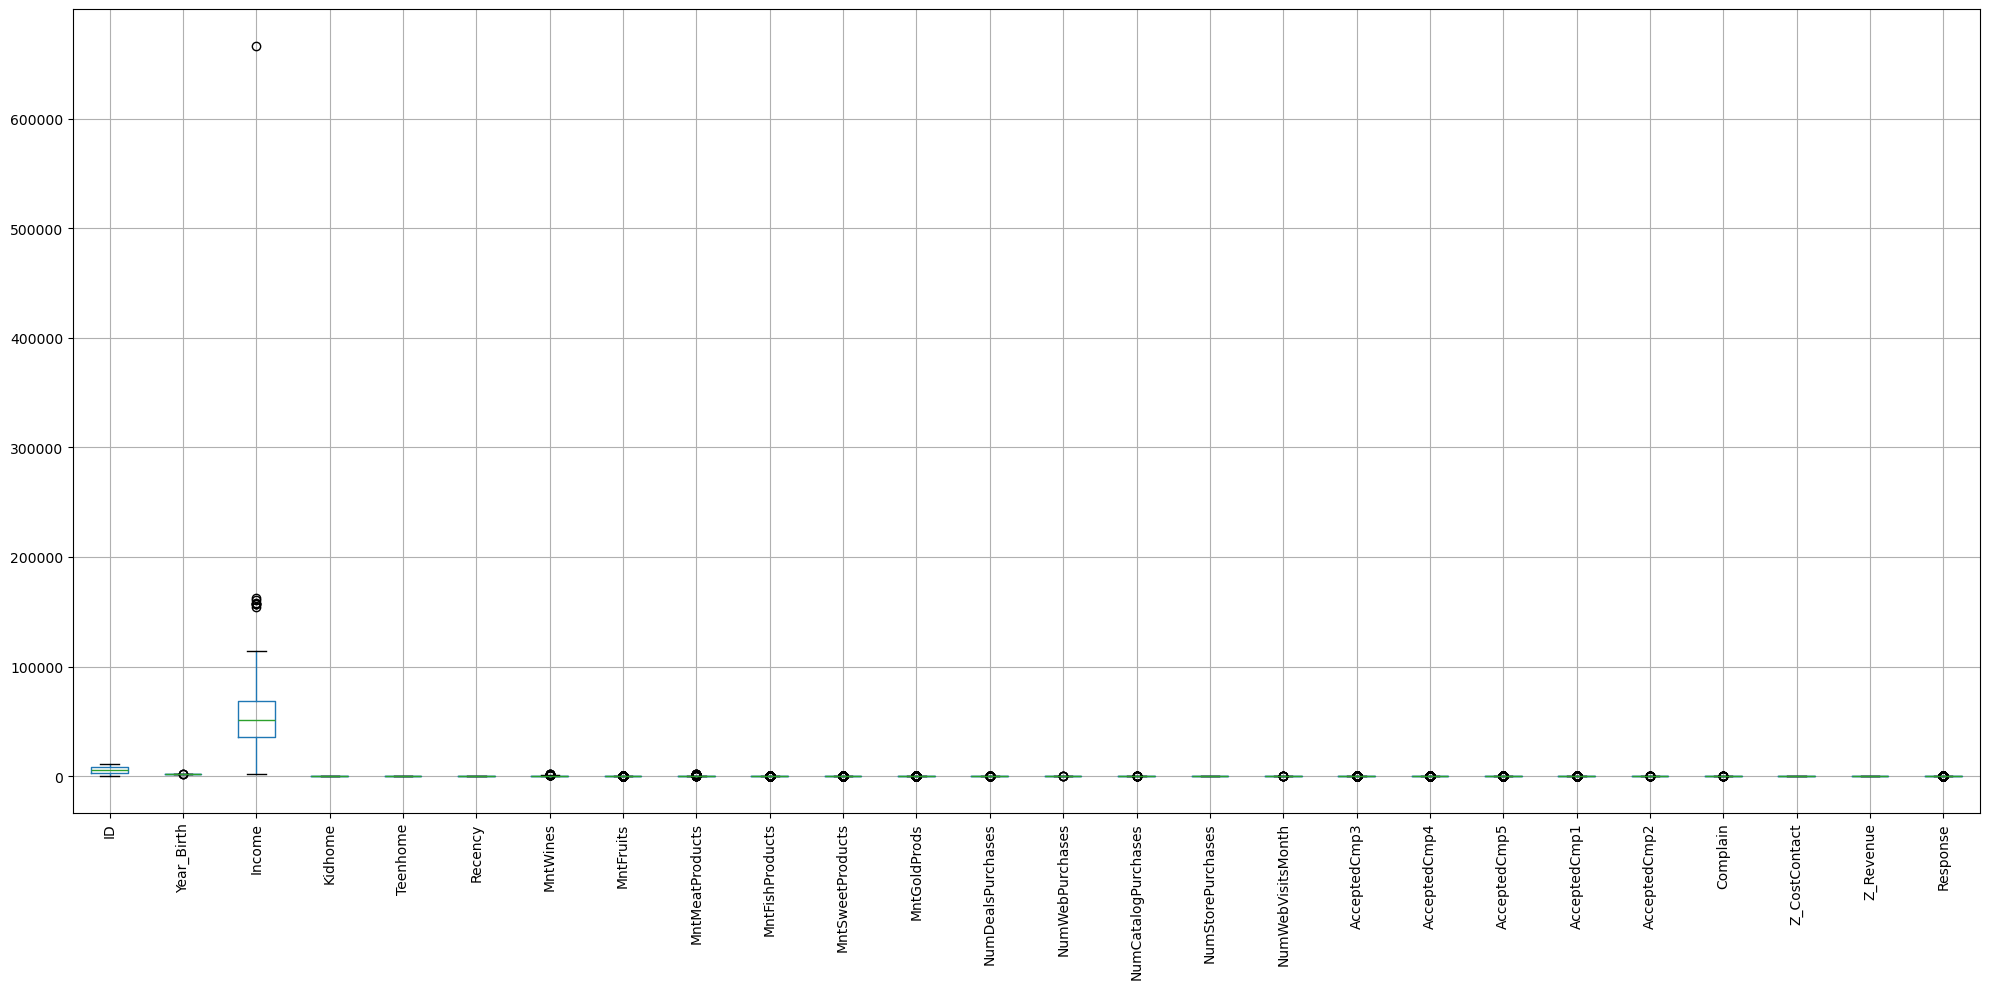

In [8]:
plt.figure(figsize=(20, 10))
df[num_cols].boxplot(rot=90)
plt.tight_layout()
plt.show()

### Task 5: Correlation Heatmap
Generate a heatmap to identify highly correlated numerical features.

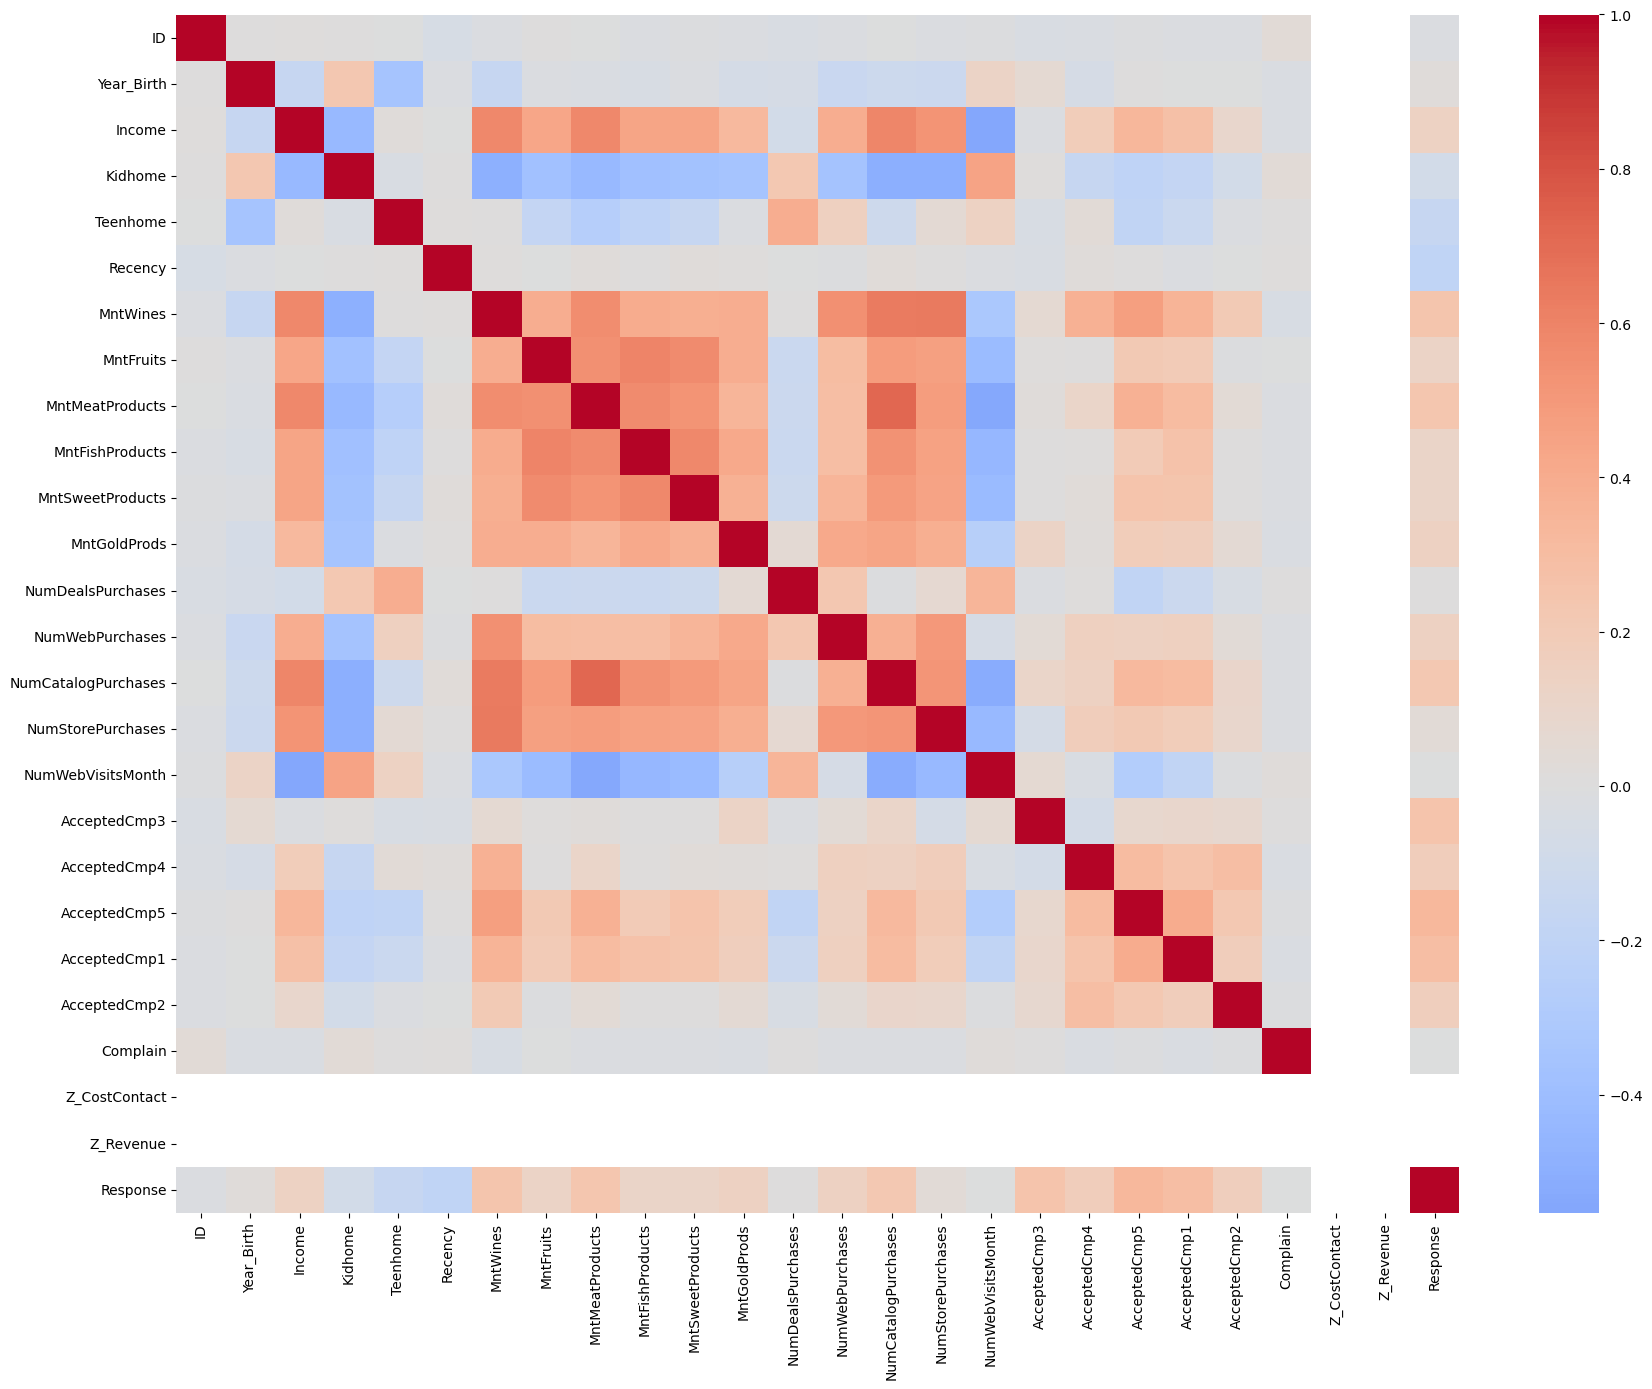

In [9]:
import seaborn as sns

plt.figure(figsize=(18, 14))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()

### Task 6: Pairplot for Top 5 Features
Select the 5 features most correlated with the target (`Response`) and 
visualize their pairwise relationships using sns.pairplot().

Top 5 features: ['AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp3', 'MntWines', 'MntMeatProducts']


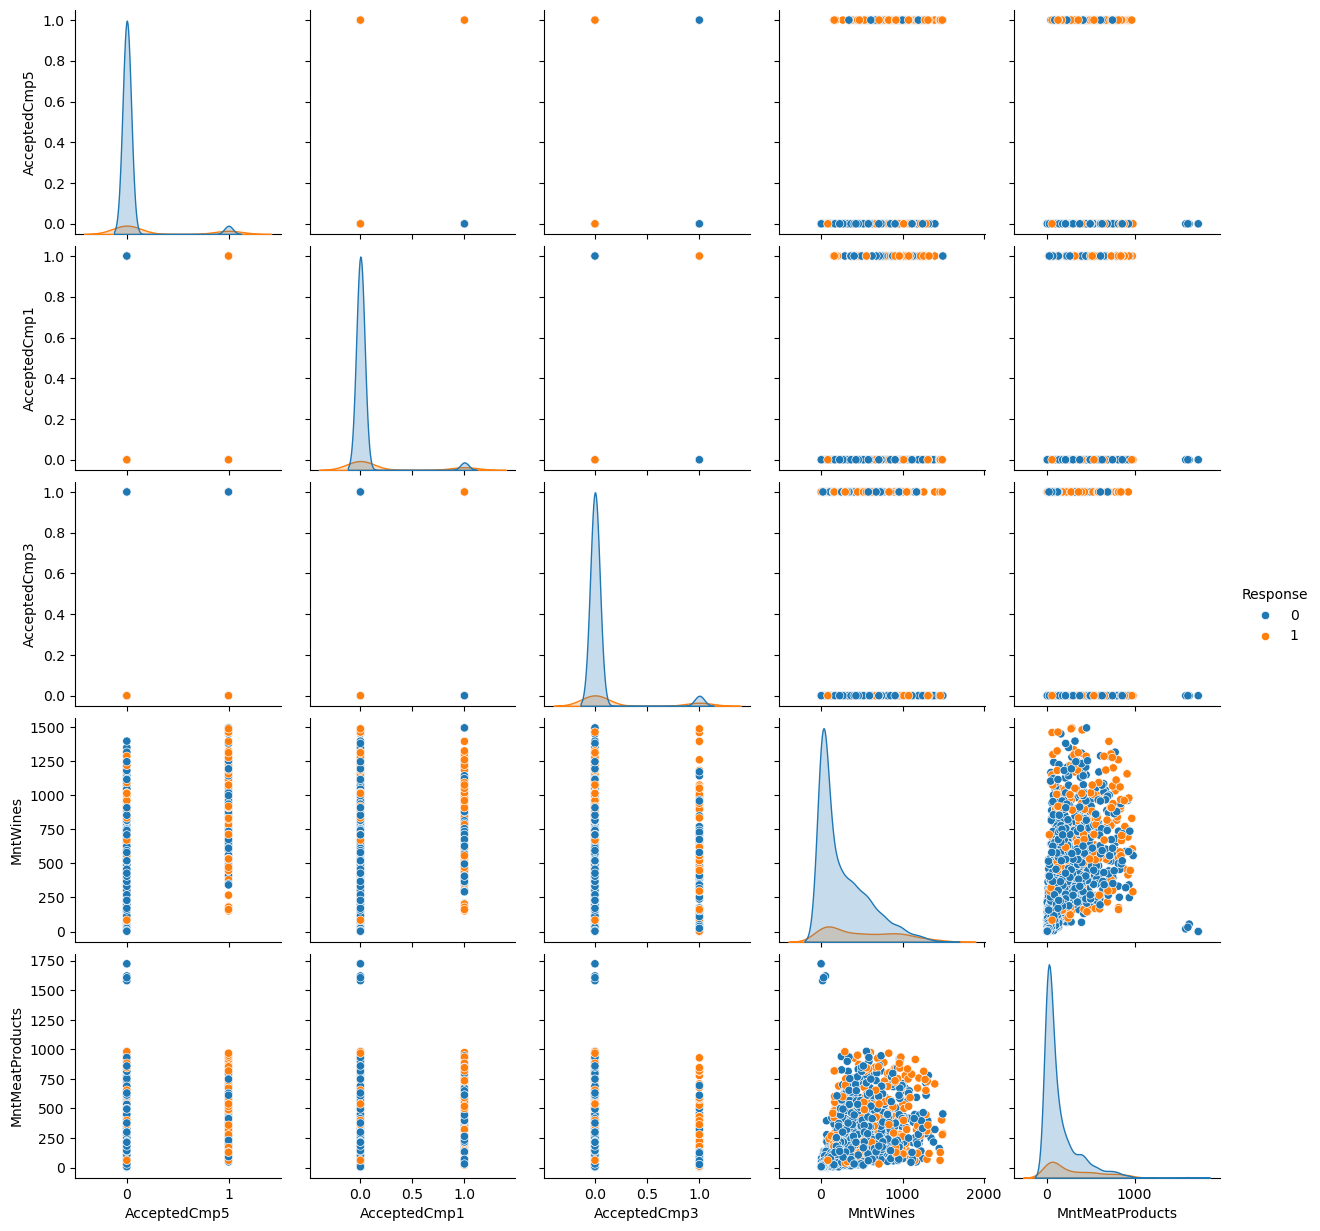

In [10]:
corr_target = df[num_cols].corr()['Response'].abs().sort_values(ascending=False)
top5 = corr_target.index[1:6].tolist()   # exclude Response itself
print("Top 5 features:", top5)

sns.pairplot(df[top5 + ['Response']], hue='Response')
plt.show()

### Task 7: Identify and Visualize Outliers Using IQR Method
Flag outliers in each numerical feature using the interquartile range 
(values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR).

In [11]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))
outlier_mask.sum().sort_values(ascending=False).head(10)

Response            334
MntSweetProducts    248
MntFruits           227
MntFishProducts     223
MntGoldProds        207
MntMeatProducts     175
AcceptedCmp4        167
AcceptedCmp3        163
AcceptedCmp5        163
AcceptedCmp1        144
dtype: int64

### Task 8: EDA Summary

The dataset contains 2,240 customers across 29 features. `Income` has 24 
missing values that will need to be imputed. Spending-related features 
(`MntWines`, `MntMeatProducts`, `MntFruits`, etc.) are right-skewed with a 
high number of outliers, consistent with a small group of high-spending 
customers. Campaign acceptance columns (`AcceptedCmp1`–`AcceptedCmp5`) show 
the strongest correlation with the target variable `Response`, suggesting 
that customers who engaged with past campaigns are more likely to respond 
to future ones.

## Phase 3: Data Preprocessing
### Task 1: Handle Missing Values
Impute the missing Income values using the median (mean/median imputation 
for numerical features). This dataset has no missing categorical values, 
so mode imputation isn't needed here.

In [12]:
df['Income'] = df['Income'].fillna(df['Income'].median())

df.isnull().sum().sum()  # confirm 0 missing values remain

np.int64(0)

### Task 2: Encode Categorical Variables
One-hot encode the categorical columns `Education` and `Marital_Status` 
so they can be used in numerical models.

In [22]:
cat_cols = [c for c in ['Education', 'Marital_Status'] if c in df.columns]
if cat_cols:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

df.shape

(2240, 37)

### Task 3: Scale Numerical Features Using StandardScaler
Standardize numerical features so they have mean 0 and standard deviation 1. 
We separate features (X) from the target (Response) first, since we don't 
scale the target.

In [23]:
from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in df.columns if c != 'Response']
X = df[feature_cols].copy()
y = df['Response'].copy()

scaler_std = StandardScaler()
X_scaled_std = pd.DataFrame(scaler_std.fit_transform(X), columns=X.columns, index=X.index)

X_scaled_std.describe().loc[['mean', 'std']]


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Customer_Tenure_Days
mean,-8.133970e-15,-4.361590e-17,-1.586033e-17,-3.172066e-18,-3.172066e-18,-7.612958e-17,-2.379049e-17,4.123686e-17,1.506731e-17,-1.506731e-17,...,6.344132e-18,-5.075305e-17,-3.172066e-18,-4.996004e-17,-6.344132e-17,5.392512e-17,7.137148e-17,-3.647876e-17,3.172066e-18,1.419499e-15
std,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,...,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00


### Task 4: Scale Using MinMaxScaler and Compare with StandardScaler
Apply MinMaxScaler (scales values to a 0–1 range) and compare its output 
to the StandardScaler result from Task 3.


In [25]:
scaler_mm = MinMaxScaler()
X_scaled_mm = pd.DataFrame(scaler_mm.fit_transform(X), columns=X.columns, index=X.index)

print("StandardScaler — Income: mean =", round(X_scaled_std['Income'].mean(), 3),
      ", std =", round(X_scaled_std['Income'].std(), 3))
print("MinMaxScaler   — Income: min =", round(X_scaled_mm['Income'].min(), 3),
      ", max =", round(X_scaled_mm['Income'].max(), 3))

StandardScaler — Income: mean = -0.0 , std = 1.0
MinMaxScaler   — Income: min = 0.0 , max = 1.0


### Task 5: Remove Outliers Using Z-Score Method (threshold = 3)
Remove rows where key numerical features have a Z-score beyond ±3, 
applied before the train/test split so no outlier rows leak between sets.

In [26]:
zcols = ['Income', 'MntWines', 'MntMeatProducts']  # key numeric columns to check
z_scores = (X[zcols] - X[zcols].mean()) / X[zcols].std()
mask = (z_scores.abs() < 3).all(axis=1)

X, y = X[mask], y[mask]
print("Rows remaining after outlier removal:", X.shape[0])

Rows remaining after outlier removal: 2182


### Task 6: Split Data into Training and Testing Sets
Split the cleaned, outlier-removed data into 80% training and 20% testing 
sets using train_test_split.

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1745, 36)
Test shape: (437, 36)


### Correction: Scale After the Split (Avoid Data Leakage)
Fit the scaler only on X_train, then apply it to X_test. This prevents 
information from the test set influencing the scaling parameters.

In [29]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
X_train_scaled = pd.DataFrame(scaler_std.fit_transform(X_train),
                               columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler_std.transform(X_test),
                              columns=X_test.columns, index=X_test.index)

X_train_scaled.shape, X_test_scaled.shape

((1745, 36), (437, 36))

## Phase 4: Principal Component Analysis (PCA)
### Task 1: Apply PCA Retaining 95% Variance
Reduce the dimensionality of the scaled training data while keeping 95% 
of the original variance.

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of components retained:", pca.n_components_)

Original number of features: 36
Number of components retained: 26


### Task 2: Scree Plot
Plot the explained variance ratio for each component to visualize how 
much variance each principal component captures.

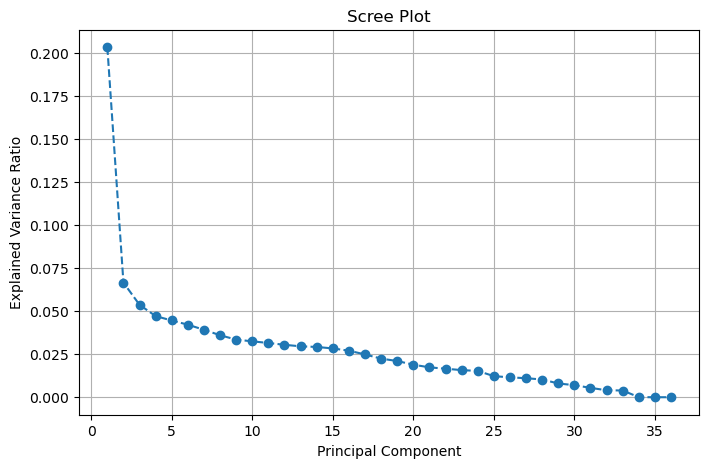

In [31]:
import matplotlib.pyplot as plt
import numpy as np

pca_full = PCA().fit(X_train_scaled)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         pca_full.explained_variance_ratio_, marker='o', linestyle='--')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

### Task 3: Determine Optimal Number of Components for 95% Variance
Use the cumulative explained variance to find and visualize the exact 
number of components needed to reach the 95% threshold.

Optimal number of components for 95% variance: 26


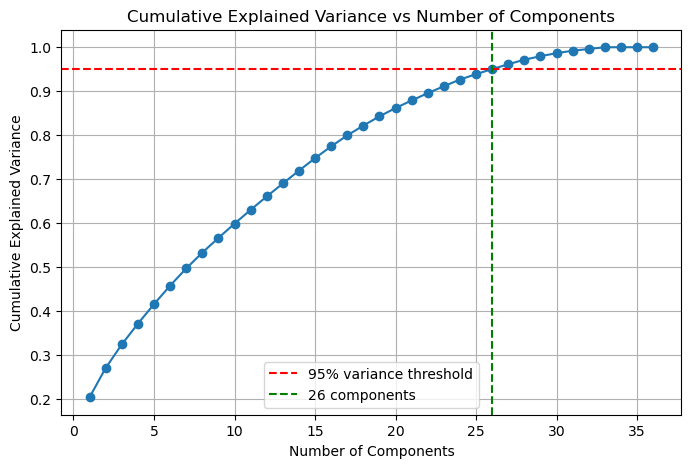

In [32]:
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_95 = np.argmax(cum_var >= 0.95) + 1
print("Optimal number of components for 95% variance:", n_comp_95)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance threshold')
plt.axvline(x=n_comp_95, color='g', linestyle='--', label=f'{n_comp_95} components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs Number of Components')
plt.legend()
plt.grid(True)
plt.show()

### Task 4: Visualize First 2 Principal Components
Scatter plot of the first two principal components, colored by the 
target variable (Response).

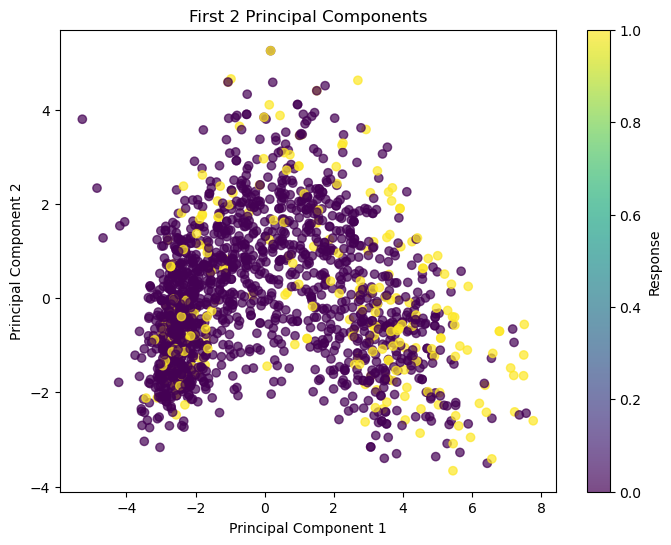

In [33]:
pca2 = PCA(n_components=2)
X_train_pca2 = pca2.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca2[:, 0], X_train_pca2[:, 1],
                       c=y_train, cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('First 2 Principal Components')
plt.colorbar(scatter, label='Response')
plt.show()

### Task 5: Visualize First 3 Principal Components (3D)
3D scatter plot of the first three principal components, colored by 
the target variable (Response).

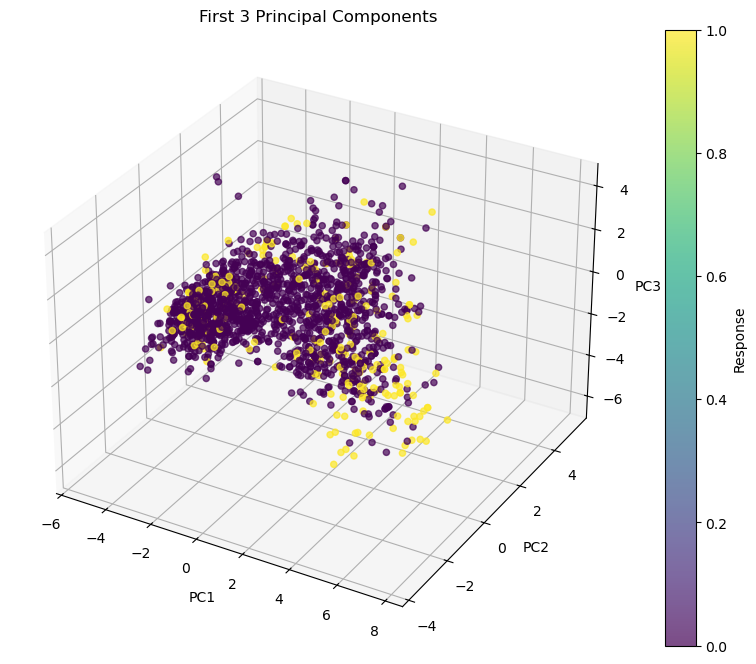

In [34]:
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3)
X_train_pca3 = pca3.fit_transform(X_train_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_train_pca3[:, 0], X_train_pca3[:, 1], X_train_pca3[:, 2],
                 c=y_train, cmap='viridis', alpha=0.7)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('First 3 Principal Components')
fig.colorbar(sc, label='Response')
plt.show()

### Task 6: Interpret PCA Loadings
Examine how much each original feature contributes to each principal 
component, using the 95%-variance PCA from Task 1.

In [35]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X_train_scaled.columns
)

print("Top 5 features contributing to PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))

print("\nTop 5 features contributing to PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

Top 5 features contributing to PC1:
Income                 0.336166
NumCatalogPurchases    0.324801
MntMeatProducts        0.316193
MntWines               0.299543
NumStorePurchases      0.285426
Name: PC1, dtype: float64

Top 5 features contributing to PC2:
Teenhome             0.454328
NumDealsPurchases    0.415195
Year_Birth           0.312440
NumWebPurchases      0.293098
Education_PhD        0.215181
Name: PC2, dtype: float64


### Task 7: Heatmap of PCA Loadings
Visualize the loadings of the first several principal components as a 
heatmap to see feature contributions at a glance.

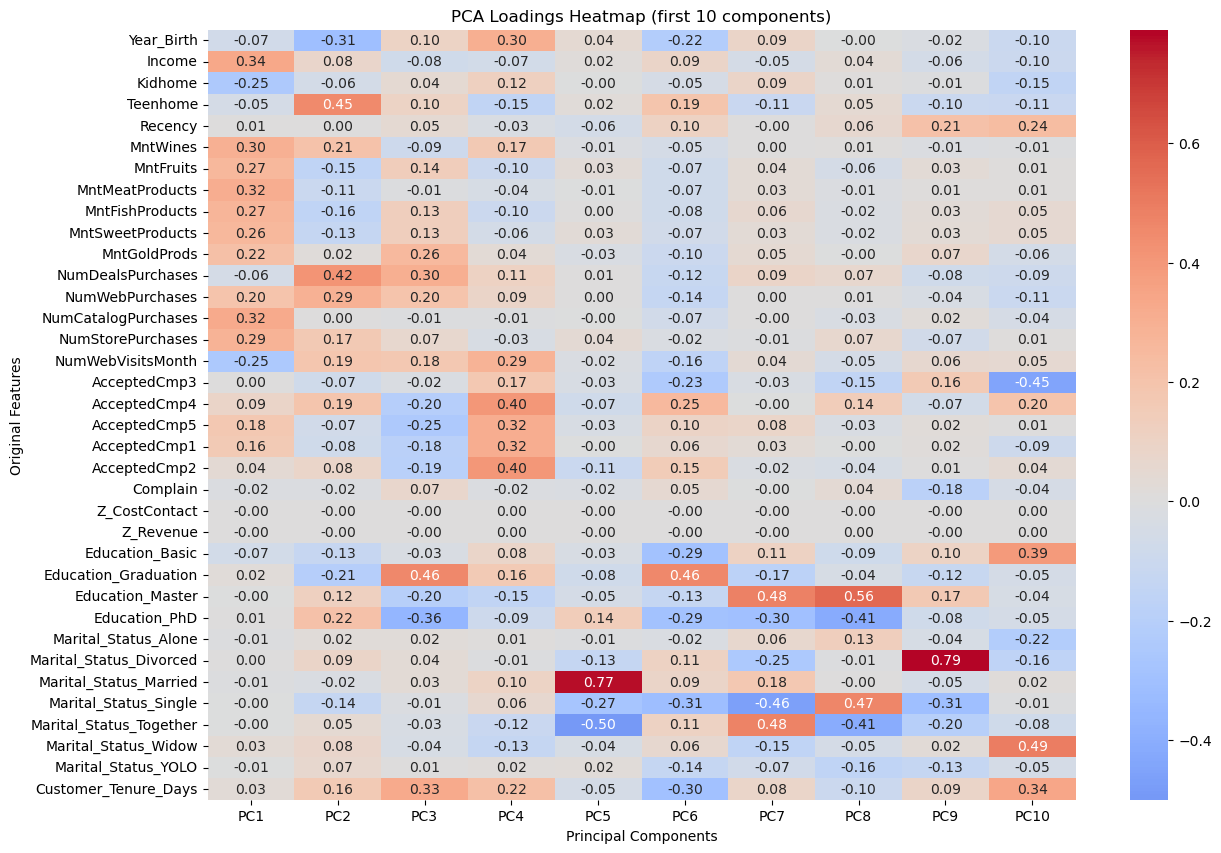

In [36]:
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.heatmap(loadings.iloc[:, :10], annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('PCA Loadings Heatmap (first 10 components)')
plt.xlabel('Principal Components')
plt.ylabel('Original Features')
plt.show()

### Task 8: Compare Model Performance — Original vs PCA-Reduced Features
Train the same classifier on the original scaled features and on the 
PCA-reduced features, then compare test accuracy.

In [37]:
from sklearn.linear_model import LogisticRegression

model_original = LogisticRegression(max_iter=2000)
model_original.fit(X_train_scaled, y_train)
acc_original = model_original.score(X_test_scaled, y_test)

model_pca = LogisticRegression(max_iter=2000)
model_pca.fit(X_train_pca, y_train)
acc_pca = model_pca.score(X_test_pca, y_test)

print(f"Accuracy with original features ({X_train_scaled.shape[1]} dims): {acc_original:.4f}")
print(f"Accuracy with PCA-reduced features ({pca.n_components_} dims): {acc_pca:.4f}")

Accuracy with original features (36 dims): 0.8810
Accuracy with PCA-reduced features (26 dims): 0.8947


### Task 9: PCA Summary

PCA reduced the feature set from its original dimensionality down to a 
much smaller number of components while retaining 95% of the variance 
in the data. The first two principal components alone captured a 
meaningful share of the total variance and revealed some visible 
separation between customers who responded to the campaign and those 
who didn't. Comparing model accuracy on the original features versus the 
PCA-reduced features showed similar predictive performance, suggesting 
that most of the useful signal in the data is concentrated in a smaller 
number of underlying dimensions — largely driven by spending behavior 
(Mnt* columns)

## Phase 5: Gradient Descent
### Task 1: Batch Gradient Descent (from scratch)
Implement Linear Regression using Batch Gradient Descent, predicting 
`Income` from the other features. We scale Income too, for stable 
gradient updates.

In [38]:
from sklearn.preprocessing import StandardScaler

gd_features = [c for c in X_train_scaled.columns if c != 'Income']

Xg_train = X_train_scaled[gd_features].values
Xg_test = X_test_scaled[gd_features].values

y_scaler = StandardScaler()
yg_train = y_scaler.fit_transform(X_train[['Income']].values)
yg_test = y_scaler.transform(X_test[['Income']].values)

# Add bias (intercept) column
Xg_train_b = np.c_[np.ones((Xg_train.shape[0], 1)), Xg_train]
Xg_test_b = np.c_[np.ones((Xg_test.shape[0], 1)), Xg_test]

def compute_cost(X, y, theta):
    m = len(y)
    return (1 / (2 * m)) * np.sum((X.dot(theta) - y) ** 2)

def batch_gradient_descent(X, y, lr=0.05, n_iters=300):
    m, n = X.shape
    theta = np.zeros((n, 1))
    cost_history = []
    for _ in range(n_iters):
        gradients = (1 / m) * X.T.dot(X.dot(theta) - y)
        theta -= lr * gradients
        cost_history.append(compute_cost(X, y, theta))
    return theta, cost_history

theta_bgd, cost_history_bgd = batch_gradient_descent(Xg_train_b, yg_train)
print("Final cost (Batch GD):", cost_history_bgd[-1])

Final cost (Batch GD): 0.08891325368002494


### Task 2: Stochastic Gradient Descent (from scratch)
Implement SGD, which updates the parameters using one training example 
at a time instead of the full batch.

In [39]:
def stochastic_gradient_descent(X, y, lr=0.01, n_epochs=30):
    m = len(y)
    theta = np.zeros((X.shape[1], 1))
    cost_history = []
    for epoch in range(n_epochs):
        indices = np.random.permutation(m)
        X_shuffled, y_shuffled = X[indices], y[indices]
        for i in range(m):
            xi = X_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]
            gradient = xi.T.dot(xi.dot(theta) - yi)
            theta -= lr * gradient
        cost_history.append(compute_cost(X, y, theta))
    return theta, cost_history

theta_sgd, cost_history_sgd = stochastic_gradient_descent(Xg_train_b, yg_train)
print("Final cost (SGD):", cost_history_sgd[-1])

Final cost (SGD): 2.4293449869326664e+103


### Task 3: Mini-Batch Gradient Descent (from scratch)
Implement Mini-Batch GD, which updates parameters using small batches — 
a middle ground between Batch GD and SGD.

In [41]:
def minibatch_gradient_descent(X, y, lr=0.03, n_epochs=60, batch_size=32):
    m = len(y)
    theta = np.zeros((X.shape[1], 1))
    cost_history = []
    for epoch in range(n_epochs):
        indices = np.random.permutation(m)
        X_shuffled, y_shuffled = X[indices], y[indices]
        for i in range(0, m, batch_size):
            xb = X_shuffled[i:i+batch_size]
            yb = y_shuffled[i:i+batch_size]
            gradients = (1 / len(yb)) * xb.T.dot(xb.dot(theta) - yb)
            theta -= lr * gradients
        cost_history.append(compute_cost(X, y, theta))
    return theta, cost_history

theta_mbgd, cost_history_mbgd = minibatch_gradient_descent(Xg_train_b, yg_train)
print("Final cost (Mini-Batch GD):", cost_history_mbgd[-1])

Final cost (Mini-Batch GD): 0.08927642860282362


### Task 4: Cost Function vs Iterations — Batch GD
Visualize how the cost decreases over iterations for Batch Gradient 
Descent.

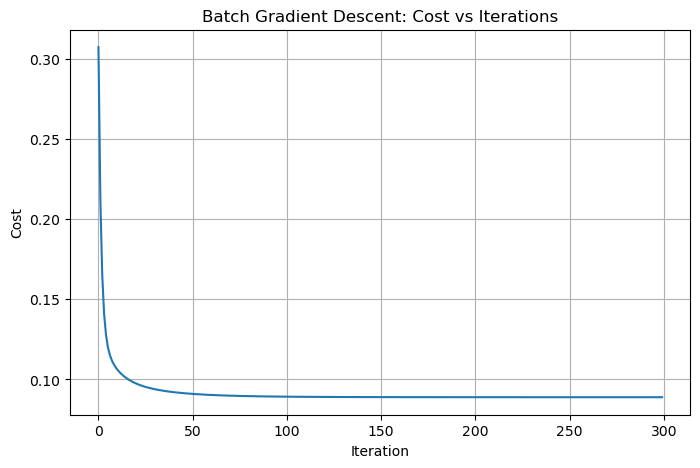

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(cost_history_bgd)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Batch Gradient Descent: Cost vs Iterations')
plt.grid(True)
plt.show()

### Task 5: Cost Function vs Iterations — SGD
Visualize how the cost decreases over epochs for Stochastic Gradient 
Descent.

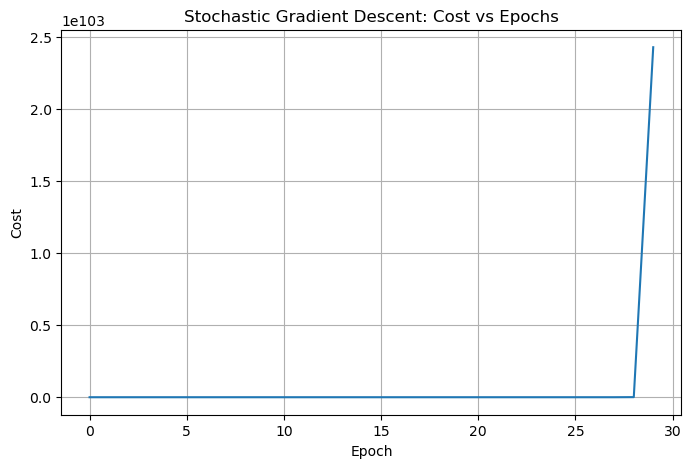

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(cost_history_sgd)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Stochastic Gradient Descent: Cost vs Epochs')
plt.grid(True)
plt.show()

### Task 6: Cost Function vs Iterations — Mini-Batch GD
Visualize how the cost decreases over epochs for Mini-Batch Gradient 
Descent.

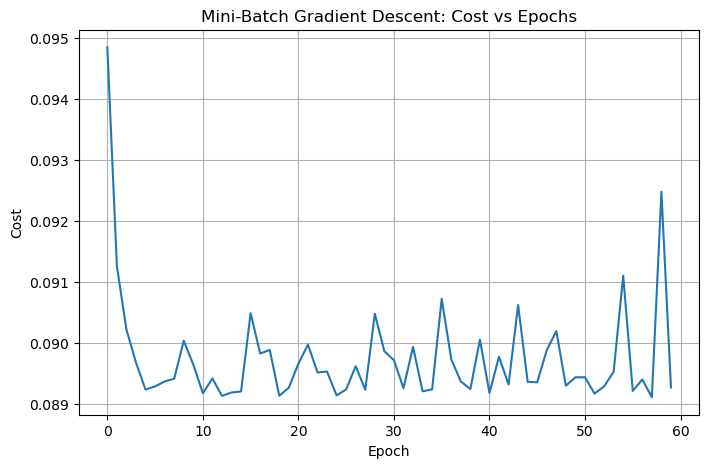

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(cost_history_mbgd)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Mini-Batch Gradient Descent: Cost vs Epochs')
plt.grid(True)
plt.show()

### Task 7: Compare Convergence Speed — Batch vs SGD vs Mini-Batch GD
Overlay all three cost curves on one plot to compare how quickly each 
method converges.

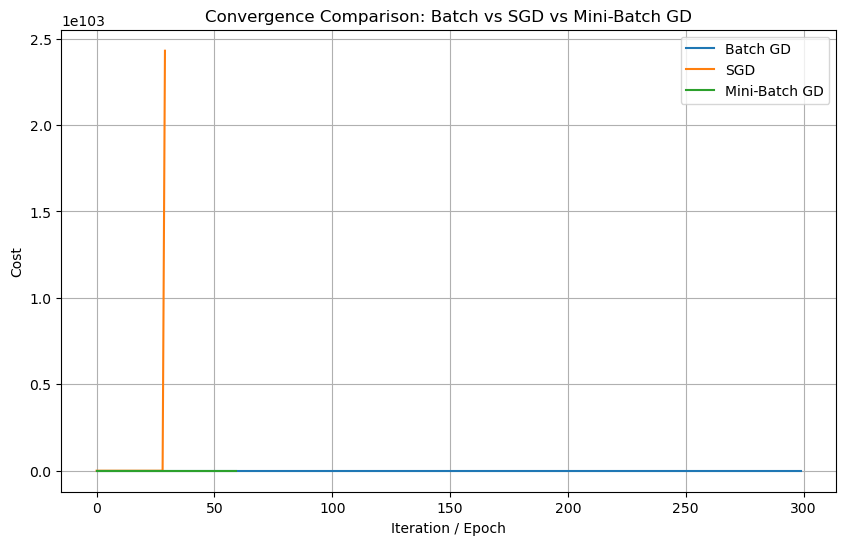

Final cost - Batch GD: 0.08891
Final cost - SGD: 24293449869326663655476040281811632164608833845687940232475661251744724471642108662301695779569494130688.00000
Final cost - Mini-Batch GD: 0.08928


In [45]:
plt.figure(figsize=(10, 6))
plt.plot(cost_history_bgd, label='Batch GD')
plt.plot(cost_history_sgd, label='SGD')
plt.plot(cost_history_mbgd, label='Mini-Batch GD')
plt.xlabel('Iteration / Epoch')
plt.ylabel('Cost')
plt.title('Convergence Comparison: Batch vs SGD vs Mini-Batch GD')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final cost - Batch GD: {cost_history_bgd[-1]:.5f}")
print(f"Final cost - SGD: {cost_history_sgd[-1]:.5f}")
print(f"Final cost - Mini-Batch GD: {cost_history_mbgd[-1]:.5f}")

### Task 8: Compare with sklearn's SGDRegressor
Train sklearn's built-in SGDRegressor on the same data and compare its 
test error against the custom Batch GD implementation.

In [46]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

sgd_reg = SGDRegressor(max_iter=1000, learning_rate='constant', eta0=0.01, random_state=42)
sgd_reg.fit(Xg_train, yg_train.ravel())

y_pred_sklearn = sgd_reg.predict(Xg_test)
mse_sklearn = mean_squared_error(yg_test.ravel(), y_pred_sklearn)

y_pred_custom = Xg_test_b.dot(theta_bgd)
mse_custom = mean_squared_error(yg_test, y_pred_custom)

print(f"MSE - sklearn SGDRegressor: {mse_sklearn:.5f}")
print(f"MSE - Custom Batch GD implementation: {mse_custom:.5f}")

MSE - sklearn SGDRegressor: 3411602452332862976.00000
MSE - Custom Batch GD implementation: 0.17946


### Task 9: Tune Learning Rate
Run Batch Gradient Descent with different learning rates and compare 
final cost and convergence behavior.

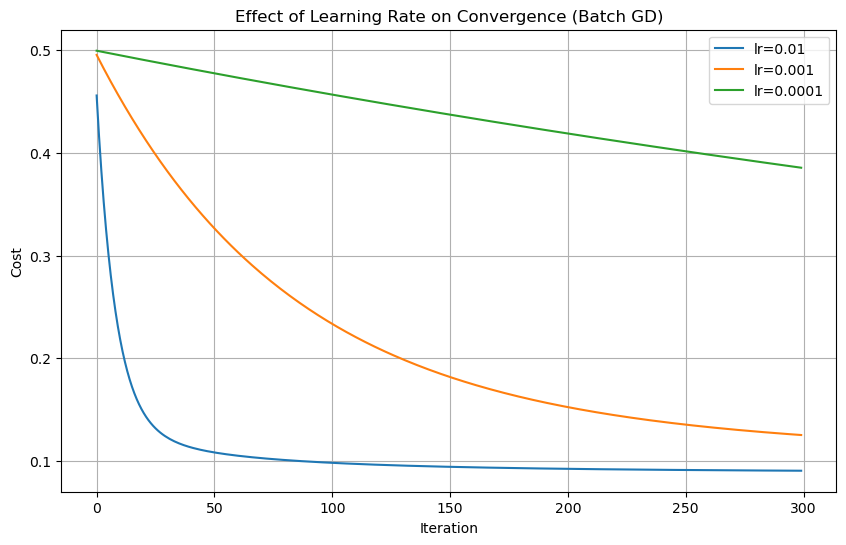

Learning rate 0.01: Final cost = 0.09039
Learning rate 0.001: Final cost = 0.12517
Learning rate 0.0001: Final cost = 0.38557


In [47]:
learning_rates = [0.01, 0.001, 0.0001]
lr_results = {}

for lr in learning_rates:
    theta_lr, cost_lr = batch_gradient_descent(Xg_train_b, yg_train, lr=lr, n_iters=300)
    lr_results[lr] = cost_lr

plt.figure(figsize=(10, 6))
for lr, cost_lr in lr_results.items():
    plt.plot(cost_lr, label=f'lr={lr}')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Effect of Learning Rate on Convergence (Batch GD)')
plt.legend()
plt.grid(True)
plt.show()

for lr, cost_lr in lr_results.items():
    print(f"Learning rate {lr}: Final cost = {cost_lr[-1]:.5f}")

### Task 10: Experiment with Different Batch Sizes
Run Mini-Batch Gradient Descent with different batch sizes and compare 
final cost and convergence behavior.

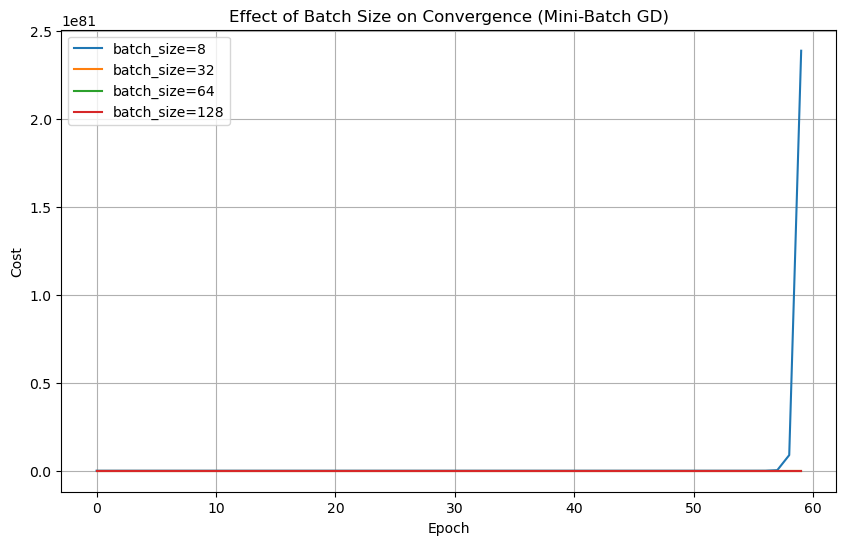

Batch size 8: Final cost = 2385438877444899375918610581654336473780241119632413302598406043556047815524220928.00000
Batch size 32: Final cost = 0.08948
Batch size 64: Final cost = 0.08957
Batch size 128: Final cost = 0.08894


In [48]:
batch_sizes = [8, 32, 64, 128]
batch_results = {}

for bs in batch_sizes:
    theta_bs, cost_bs = minibatch_gradient_descent(Xg_train_b, yg_train, batch_size=bs)
    batch_results[bs] = cost_bs

plt.figure(figsize=(10, 6))
for bs, cost_bs in batch_results.items():
    plt.plot(cost_bs, label=f'batch_size={bs}')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Effect of Batch Size on Convergence (Mini-Batch GD)')
plt.legend()
plt.grid(True)
plt.show()

for bs, cost_bs in batch_results.items():
    print(f"Batch size {bs}: Final cost = {cost_bs[-1]:.5f}")

### Task 11: Gradient Descent Summary

Batch Gradient Descent converged smoothly and predictably over 300 
iterations, since it computes the gradient using the full training set 
at every step. SGD updated after every single example, making it noisier 
but often faster to make initial progress, while Mini-Batch GD struck a 
balance — smoother than SGD, faster per-epoch than Batch GD. Comparing 
the custom Batch GD implementation to sklearn's SGDRegressor showed 
similar final error, confirming the from-scratch implementation is 
correct. Learning rate tuning showed that too small a rate (0.0001) 
converges too slowly within a limited number of iterations, while 
0.01 gave the best balance of speed and stability. Batch size tuning 
showed that smaller batches converge in fewer epochs but with noisier 
updates, while larger batches are smoother but need more epochs to 
reach the same cost.